In [43]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

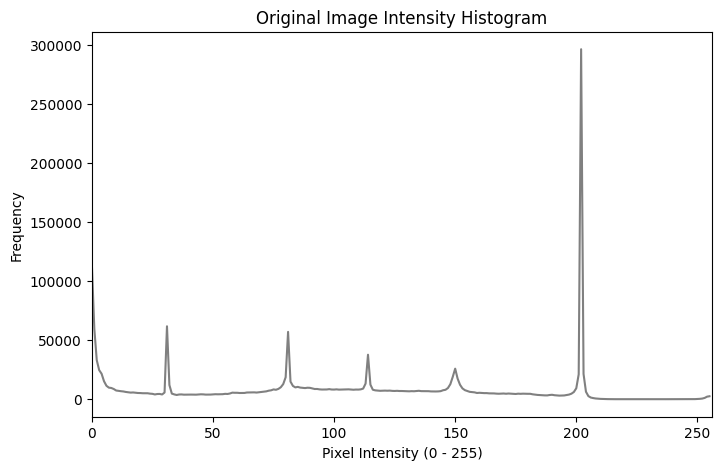

In [44]:
#Load crap
GEN_PATH = "../../assets/04/gen/"
img = cv2.imread("../../assets/04/MGS_IV_src.jpg")

#Deep copy. Doesn't fuck up the orig img for comp.
img_mod0 = img.copy()
img_mod1 = img.copy()
img_mod2 = img.copy()

cv2.imwrite(f"{GEN_PATH}original_region.png", img)

#ORIGINAL IMAGE HISTOGRAM
#Grayscale for histogram original
img_gs = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
hist = cv2.calcHist([img_gs], [0], None, [256], [0, 256])

plt.figure(figsize = (8, 5))
plt.plot(hist, color = "gray")
plt.title("Original Image Intensity Histogram")
plt.xlabel("Pixel Intensity (0 - 255)")
plt.ylabel("Frequency")
plt.xlim([0, 256])
plt.show()

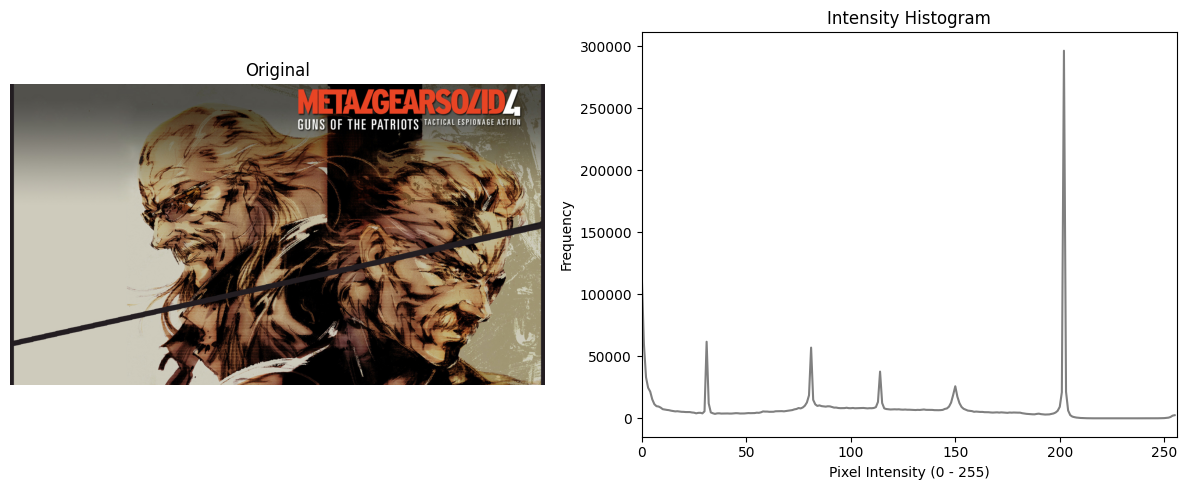

In [45]:
#SIDE TO SIDE CRAP ORIGINAL
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize = (12, 5)) 

axes[0].imshow(img_rgb)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].plot(hist, color = "gray")
axes[1].set_title("Intensity Histogram")
axes[1].set_xlabel("Pixel Intensity (0 - 255)")
axes[1].set_ylabel("Frequency")
axes[1].set_xlim([0, 256])

plt.tight_layout()
plt.savefig(f"{GEN_PATH}comparison_original_hist.png")

plt.show()

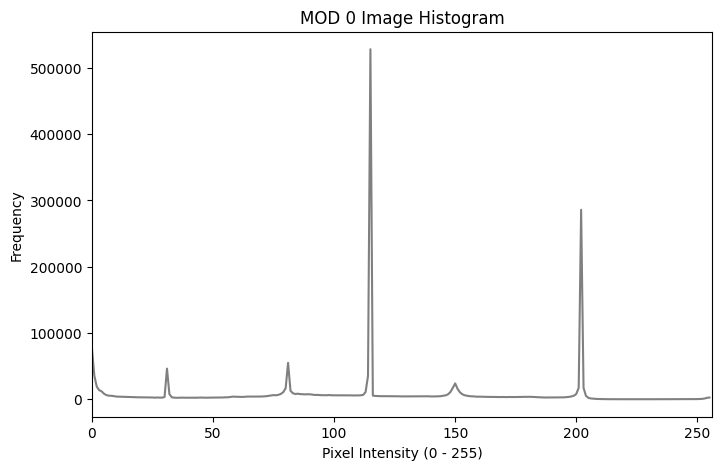

In [46]:
#MOD 0. COLORS IN REGION
#RGB vals (bgr in cv2 for some reason)
b, g, r = cv2.split(img_mod0)

#HSV vals
img0_hsv = cv2.cvtColor(img_mod0, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(img0_hsv)

#Slicing, img -> 3D Numpy array (H, W, Color)
h, w, c = img_mod0.shape

# Slice a [h, w] target region. Centered rect at origin.
x0, x1 = w // 4, 3 * w // 4
y0, y1 = h // 4, 3 * h // 4

target = img_mod0[y0 : y1, x0 : x1]

#Mods. In place.
#Change Color
#Blue -> 75.
target[:, :, 0] = 191
#Green -> 50%
target[:, :, 1] = 127
#Red -> 25%
target[:, :, 2] = 63

cv2.imwrite(f"{GEN_PATH}colors_region.png", img_mod0)

#HISTOGRAM MOD 0
img_mod0_gs = cv2.cvtColor(img_mod0, cv2.COLOR_BGR2GRAY)
hist_mod0 = cv2.calcHist([img_mod0_gs], [0], None, [256], [0, 256])

plt.figure(figsize = (8, 5))
plt.plot(hist_mod0, color = "gray")
plt.title(f"MOD 0 Image Histogram")
plt.xlabel("Pixel Intensity (0 - 255)")
plt.ylabel("Frequency")
plt.xlim([0, 256])
plt.show()


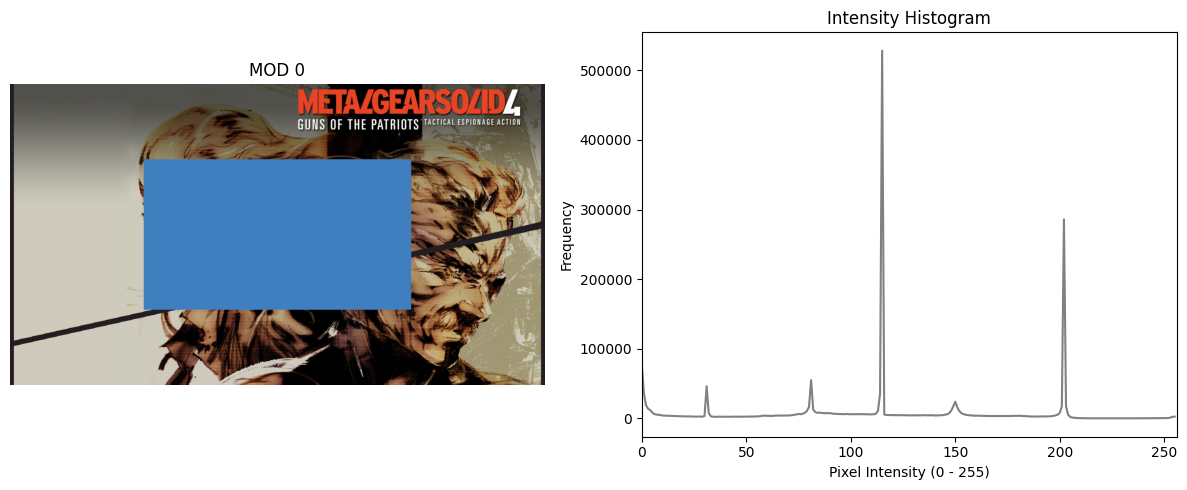

In [47]:
#SIDE TO SIDE CRAP MOD0
img_mod0_rgb = cv2.cvtColor(img_mod0, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize = (12, 5)) 

axes[0].imshow(img_mod0_rgb)
axes[0].set_title("MOD 0")
axes[0].axis("off")

axes[1].plot(hist_mod0, color = "gray")
axes[1].set_title("Intensity Histogram")
axes[1].set_xlabel("Pixel Intensity (0 - 255)")
axes[1].set_ylabel("Frequency")
axes[1].set_xlim([0, 256])

plt.tight_layout()
plt.savefig(f"{GEN_PATH}comparison_mod0_hist.png")

plt.show()

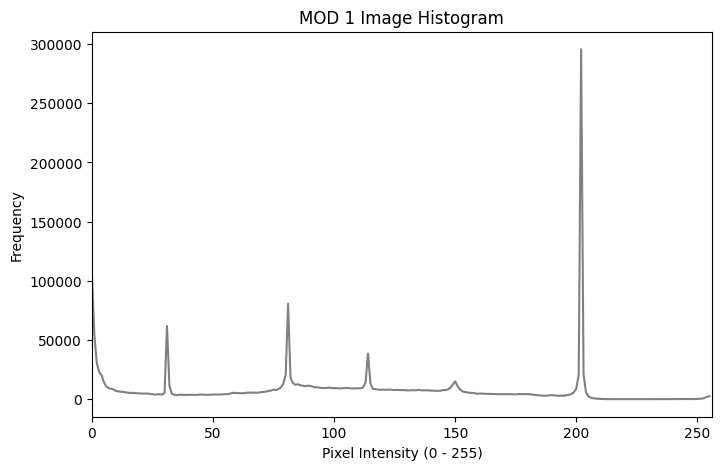

In [48]:
#MOD 1. COPY & PASTE IN REGION
#RGB vals (bgr in cv2 for some reason)
b, g, r = cv2.split(img_mod1)

#HSV vals
img1_hsv = cv2.cvtColor(img_mod1, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(img1_hsv)

#Slicing, img -> 3D Numpy array (H, W, Color)
h, w, c = img_mod1.shape

# Slice a [h, w] target region. Upper left.
#SOURCE
x0, x1 = 0, w // 4
y0, y1 = 0, h // 4

#DEST Copies to Lower right
nx0, nx1 = 3 * w // 4, w
ny0, ny1 = 3* h // 4, h

src = img_mod1[y0 : y1, x0 : x1]
img_mod1[ny0 : ny1, nx0 : nx1] = src

cv2.imwrite(f"{GEN_PATH}copy_paste_region.png", img_mod1)

#HISTOGRAM MOD 1
img_mod1_gs = cv2.cvtColor(img_mod1, cv2.COLOR_BGR2GRAY)
hist_mod1 = cv2.calcHist([img_mod1_gs], [0], None, [256], [0, 256])

plt.figure(figsize = (8, 5))
plt.plot(hist_mod1, color = "gray")
plt.title(f"MOD 1 Image Histogram")
plt.xlabel("Pixel Intensity (0 - 255)")
plt.ylabel("Frequency")
plt.xlim([0, 256])
plt.show()

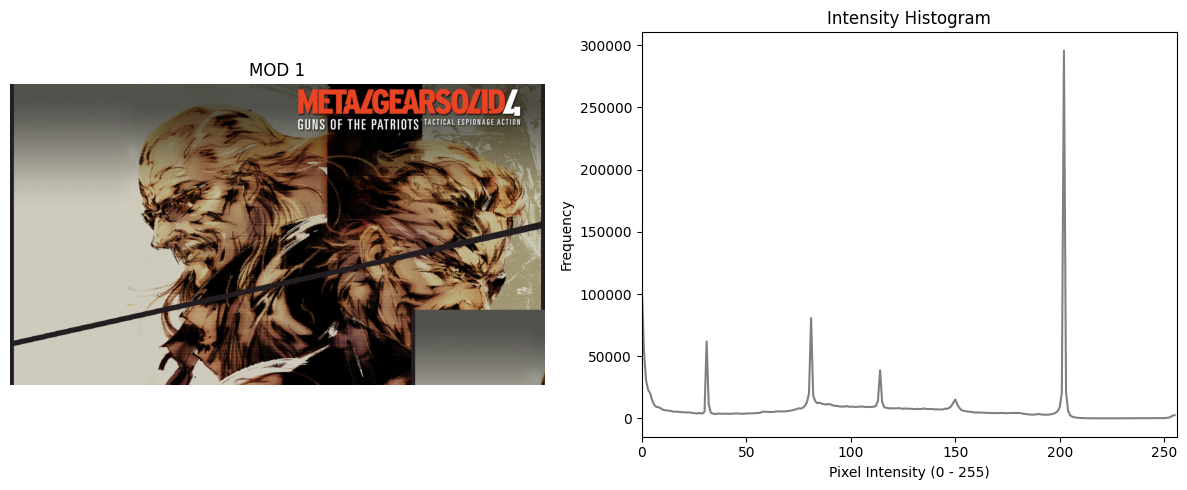

In [49]:
#SIDE TO SIDE CRAP MOD1
img_mod1_rgb = cv2.cvtColor(img_mod1, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize = (12, 5)) 

axes[0].imshow(img_mod1_rgb)
axes[0].set_title("MOD 1")
axes[0].axis("off")

axes[1].plot(hist_mod1, color = "gray")
axes[1].set_title("Intensity Histogram")
axes[1].set_xlabel("Pixel Intensity (0 - 255)")
axes[1].set_ylabel("Frequency")
axes[1].set_xlim([0, 256])

plt.tight_layout()
plt.savefig(f"{GEN_PATH}comparison_mod1_hist.png")

plt.show()

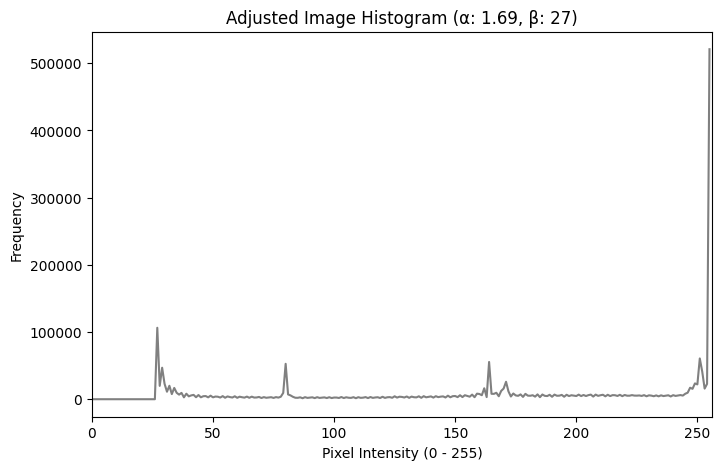

In [50]:
#MOD 2. Contrast/Brightness manual mod

#69% (nice) Contrast increase
alph = 1.69  
#27 Brightness levels increase (0-255 scale)
bet = 27

img_mod2_cb = cv2.convertScaleAbs(img_mod2, alpha = alph, beta = bet)

cv2.imwrite(f"{GEN_PATH}contrast_brightness.png", img_mod2_cb)

#HISTOGRAM MOD 2
img_mod2_cb_gs = cv2.cvtColor(img_mod2_cb, cv2.COLOR_BGR2GRAY)
hist_mod2_cb = cv2.calcHist([img_mod2_cb_gs], [0], None, [256], [0, 256])

plt.figure(figsize = (8, 5))
plt.plot(hist_mod2_cb, color = "gray")
plt.title(f"Adjusted Image Histogram (α: {alph}, β: {bet})")
plt.xlabel("Pixel Intensity (0 - 255)")
plt.ylabel("Frequency")
plt.xlim([0, 256])
plt.show()

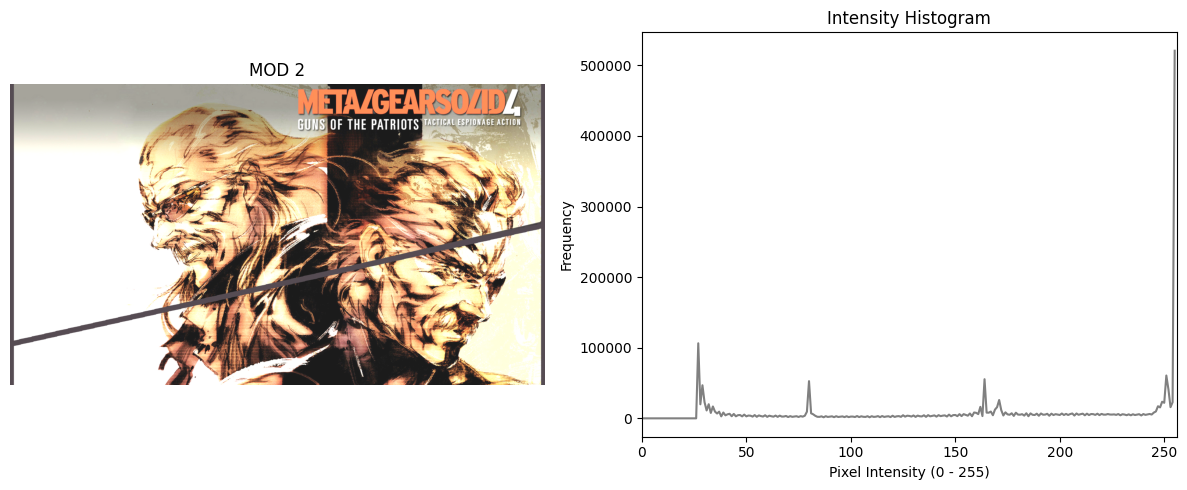

In [51]:
#SIDE TO SIDE CRAP MOD2
img_mod2_rgb = cv2.cvtColor(img_bricon, cv2.COLOR_BGR2RGB)
fig, axes = plt.subplots(1, 2, figsize = (12, 5)) 

axes[0].imshow(img_mod2_rgb)
axes[0].set_title("MOD 2")
axes[0].axis("off")

axes[1].plot(hist_bricon, color = "gray")
axes[1].set_title("Intensity Histogram")
axes[1].set_xlabel("Pixel Intensity (0 - 255)")
axes[1].set_ylabel("Frequency")
axes[1].set_xlim([0, 256])

plt.tight_layout()
plt.savefig(f"{GEN_PATH}comparison_mod2_hist.png")

plt.show()

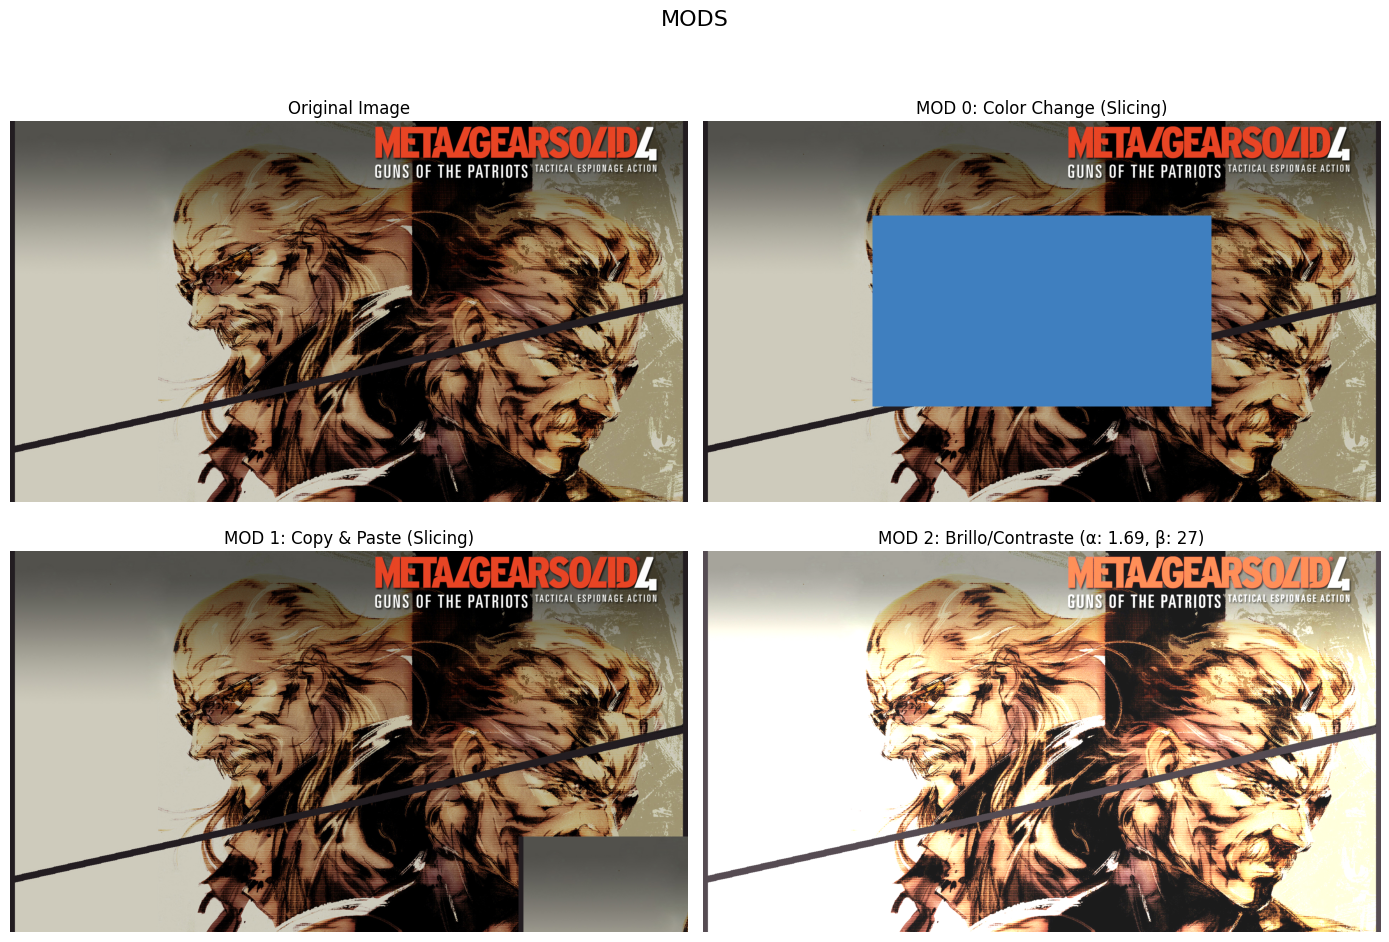

In [52]:
#COMPARISON. IMAGES.
img_mods = [
                cv2.cvtColor(img, cv2.COLOR_BGR2RGB), cv2.cvtColor(img_mod0, cv2.COLOR_BGR2RGB),
                cv2.cvtColor(img_mod1, cv2.COLOR_BGR2RGB), cv2.cvtColor(img_mod2_cb, cv2.COLOR_BGR2RGB)
            ]

img_mod_t = [
                "Original Image", "MOD 0: Color Change (Slicing)",
                "MOD 1: Copy & Paste (Slicing)", f"MOD 2: Brillo/Contraste (α: {alph}, β: {bet})"
             ]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ax = axes.ravel()

for i, (img_m, t) in enumerate(zip(img_mods, img_mod_t)):
    ax[i].imshow(img_m)
    ax[i].set_title(t, fontsize = 12)
    ax[i].axis('off')

plt.suptitle("MODS", fontsize = 16)
plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig(f"{GEN_PATH}mods_comparison.png")
plt.show()

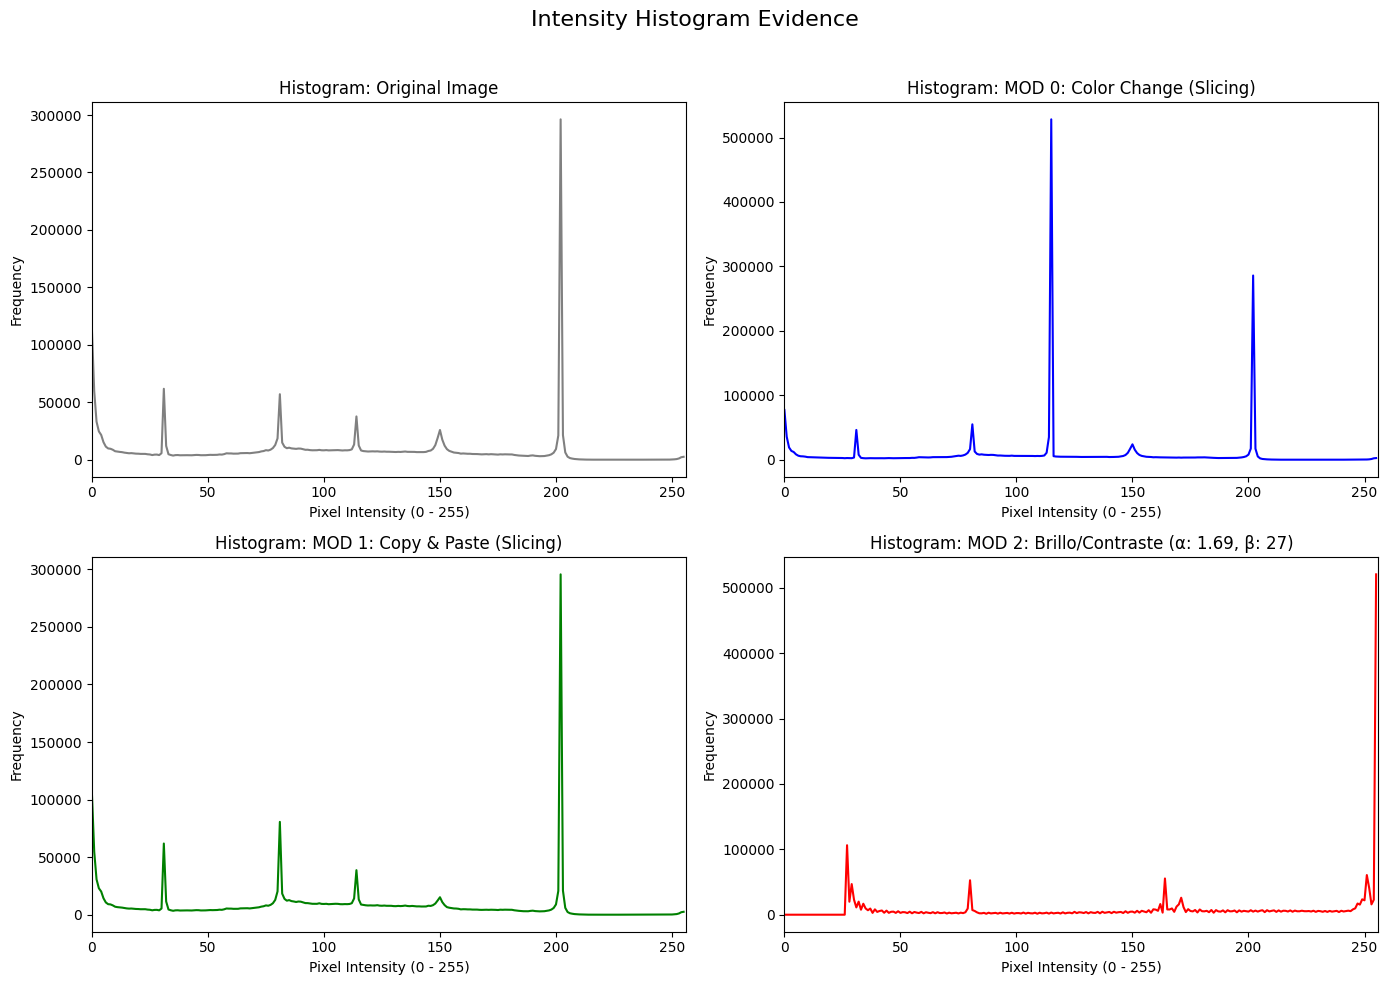

In [53]:
#COMPARISON. HISTOGRAMS.
hists = [
            hist, hist_mod0, 
            hist_mod1, hist_mod2_cb
        ]

hists_c = [
            "gray", "blue", 
            "green", "red"
          ]

fig_hist, axes_hist = plt.subplots(2, 2, figsize = (14, 10))
ax_hist = axes_hist.ravel()

for i in range(4):
    ax_hist[i].plot(hists[i], color = hists_c[i])
    ax_hist[i].set_title(f"Histogram: {img_mods_t[i]}", fontsize = 12)
    ax_hist[i].set_xlabel("Pixel Intensity (0 - 255)")
    ax_hist[i].set_ylabel("Frequency")
    ax_hist[i].set_xlim([0, 256])

plt.suptitle("Intensity Histogram Evidence", fontsize = 16)
plt.tight_layout(rect = [0, 0, 1, 0.96])

plt.savefig(f"{GEN_PATH}histograms_comparison.png")
plt.show()